
Training GNN+Bayes...

Training GNN Only...

Training Bayes Only...


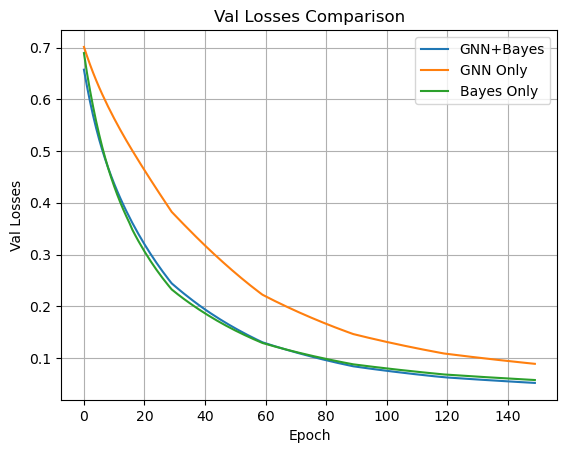

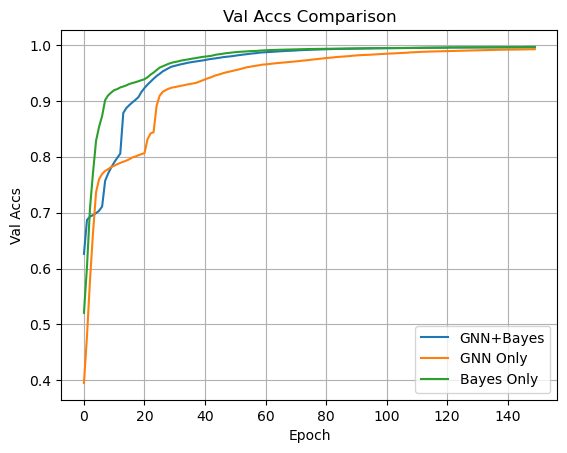

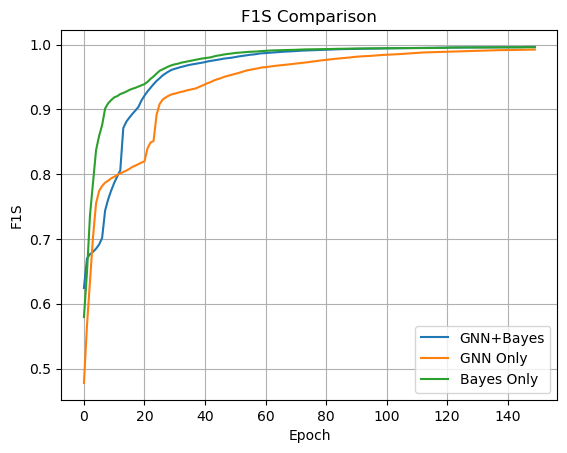

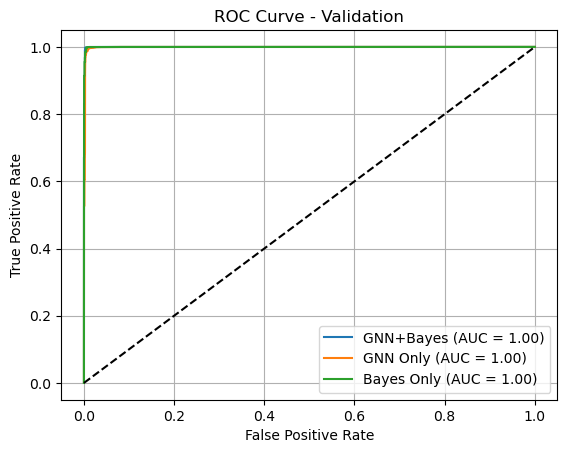

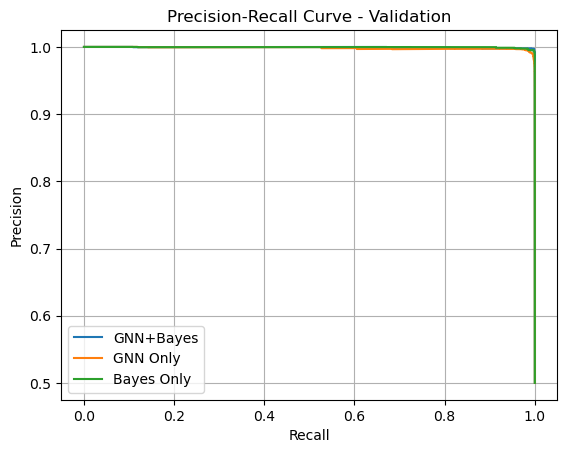

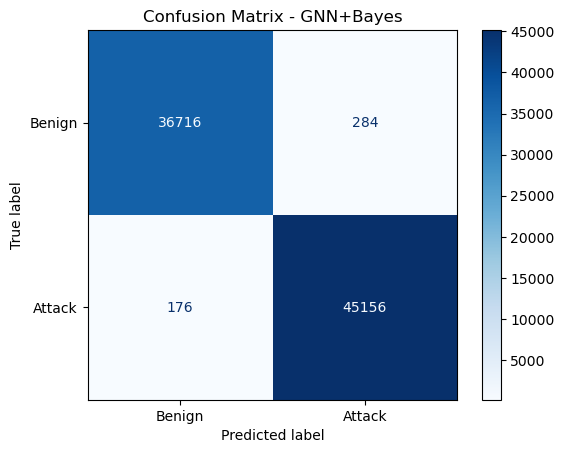

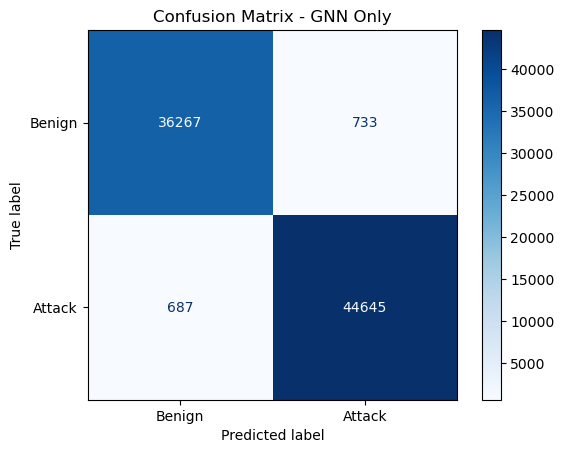

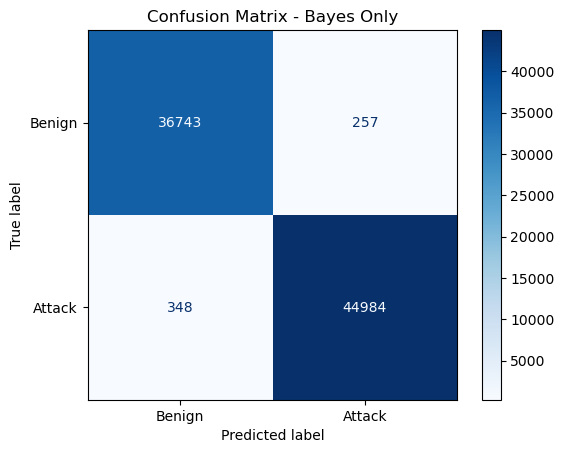

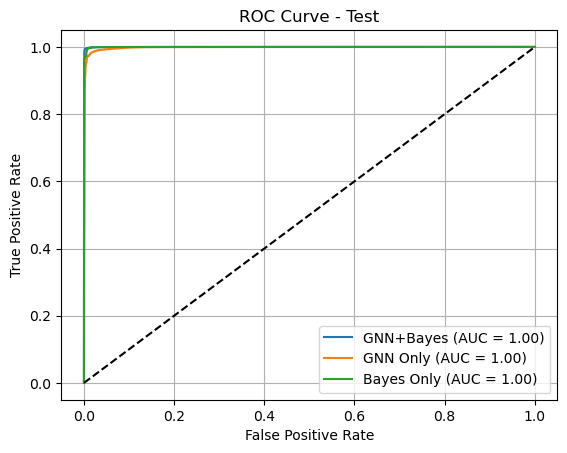

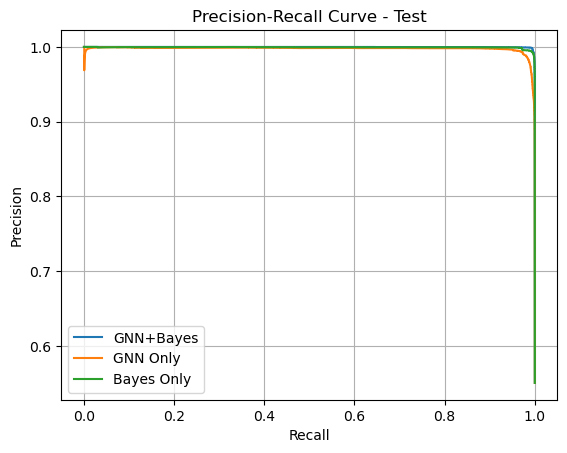

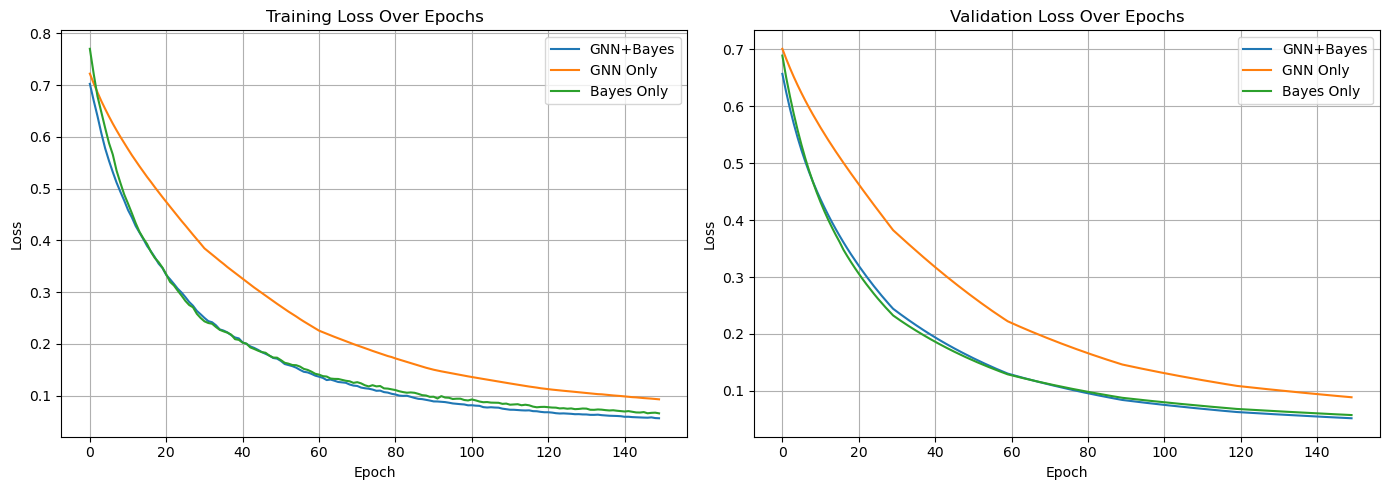

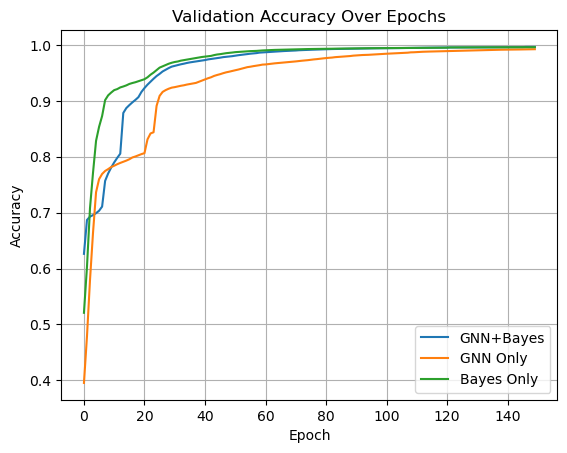


--- Comparative Evaluation on Test Set ---
            Accuracy  Precision  Recall  F1-Score     FPR     FNR
GNN+Bayes     0.9944     0.9938  0.9961    0.9949  0.0077  0.0039
GNN Only      0.9828     0.9838  0.9848    0.9843  0.0198  0.0152
Bayes Only    0.9927     0.9943  0.9923    0.9933  0.0069  0.0077


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch_geometric.nn as pyg_nn
from torch.distributions import Normal
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
)

# Set random seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Load datasets
train_df = pd.read_parquet("C:/Users/KEERTHI/anaconda3/UNSW_NB15_training-set.parquet")
test_df = pd.read_parquet("C:/Users/KEERTHI/anaconda3/UNSW_NB15_testing-set.parquet")

train_df = pd.get_dummies(train_df, drop_first=True)
test_df = pd.get_dummies(test_df, drop_first=True)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

imputer = SimpleImputer(strategy='mean')
train_df = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)
test_df = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns)

X = train_df.drop(columns=['label'])
y = train_df['label']

# SMOTE only on training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(test_df.drop(columns=['label']))
y_test = test_df['label'].values

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Models
class BayesianLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(BayesianLayer, self).__init__()
        self.mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.rho = nn.Parameter(torch.Tensor(out_features, in_features))
        self.epsilon = Normal(0, 1)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.mu)
        nn.init.constant_(self.rho, -5)

    def forward(self, x):
        sigma = torch.log1p(torch.exp(self.rho))
        weight = self.mu + sigma * self.epsilon.sample(self.mu.shape) if self.training else self.mu
        return torch.matmul(x, weight.t())

class GNN_Bayesian(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(GNN_Bayesian, self).__init__()
        self.conv1 = pyg_nn.Linear(in_features, hidden_features)
        self.dropout = nn.Dropout(p=0.3)
        self.bayesian_layer = BayesianLayer(hidden_features, out_features)

    def forward(self, x):
        x = self.conv1(x).relu()
        x = self.dropout(x)
        x = self.bayesian_layer(x)
        return torch.sigmoid(x)

class GNN_Only(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(GNN_Only, self).__init__()
        self.conv1 = pyg_nn.Linear(in_features, hidden_features)
        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.conv1(x).relu()
        x = self.dropout(x)
        x = self.fc(x)
        return torch.sigmoid(x)

class BayesianOnly(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(BayesianOnly, self).__init__()
        self.bayesian1 = BayesianLayer(in_features, hidden_features)
        self.dropout = nn.Dropout(p=0.3)
        self.bayesian2 = BayesianLayer(hidden_features, out_features)

    def forward(self, x):
        x = self.bayesian1(x).relu()
        x = self.dropout(x)
        x = self.bayesian2(x)
        return torch.sigmoid(x)

# Training and Evaluation
results = {}

def train(model, X_train, y_train, X_val, y_val, epochs=150, name="model"):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.7)
    criterion = nn.BCELoss()

    history = {"train_losses": [], "val_losses": [], "val_accs": [], "f1s": []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)

        val_pred = (val_output > 0.5).float()
        val_acc = (val_pred == y_val).sum().item() / y_val.size(0)
        val_f1 = f1_score(y_val.cpu(), val_pred.cpu())

        history["train_losses"].append(loss.item())
        history["val_losses"].append(val_loss.item())
        history["val_accs"].append(val_acc)
        history["f1s"].append(val_f1)

    results[name] = history


def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        output = model(X)
        pred = (output > 0.5).float()
        y_true = y.cpu().numpy()
        y_pred = pred.cpu().numpy()
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        return {
            "Accuracy": (pred == y).sum().item() / y.size(0),
            "Precision": precision_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred),
            "F1-Score": f1_score(y_true, y_pred),
            "FPR": fp / (fp + tn + 1e-8),
            "FNR": fn / (fn + tp + 1e-8)
        }

# Models dict
models = {
    "GNN+Bayes": GNN_Bayesian(X_train.shape[1], 96, 1),
    "GNN Only": GNN_Only(X_train.shape[1], 96, 1),
    "Bayes Only": BayesianOnly(X_train.shape[1], 96, 1)
}

metrics_summary = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    train(model, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, name=name)
    metrics_summary[name] = evaluate(model, X_test_tensor, y_test_tensor)

# Plotting
for metric in ["val_losses", "val_accs", "f1s"]:
    plt.figure()
    for name in models:
        plt.plot(results[name][metric], label=name)
    plt.title(f"{metric.replace('_', ' ').title()} Comparison")
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace('_', ' ').title())
    plt.legend()
    plt.grid(True)
    plt.show()

# ROC Curve - Validation
plt.figure()
for name in models:
    probs = models[name](X_val_tensor).detach().cpu().numpy()
    fpr, tpr, _ = roc_curve(y_val_tensor.cpu().numpy(), probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Validation")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve - Validation
plt.figure()
for name in models:
    probs = models[name](X_val_tensor).detach().cpu().numpy()
    precision, recall, _ = precision_recall_curve(y_val_tensor.cpu().numpy(), probs)
    plt.plot(recall, precision, label=name)
plt.title("Precision-Recall Curve - Validation")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Updated Confusion Matrix - Test with standard color map
for name in models:
    preds = (models[name](X_test_tensor) > 0.5).float()
    ConfusionMatrixDisplay.from_predictions(
        y_test_tensor.cpu().numpy(),
        preds.cpu().numpy(),
        display_labels=["Benign", "Attack"],
        cmap="Blues"  # Standard color map
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

# ROC Curve - Test
plt.figure()
for name in models:
    probs = models[name](X_test_tensor).detach().cpu().numpy()
    fpr, tpr, _ = roc_curve(y_test_tensor.cpu().numpy(), probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Test")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve - Test
plt.figure()
for name in models:
    probs = models[name](X_test_tensor).detach().cpu().numpy()
    precision, recall, _ = precision_recall_curve(y_test_tensor.cpu().numpy(), probs)
    plt.plot(recall, precision, label=name)
plt.title("Precision-Recall Curve - Test")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Improved Training vs Validation Loss Plot with subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']
for idx, name in enumerate(results):
    axs[0].plot(results[name]['train_losses'], label=name, color=colors[idx])
    axs[1].plot(results[name]['val_losses'], label=name, color=colors[idx])

axs[0].set_title("Training Loss Over Epochs")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].grid(True)
axs[0].legend()

axs[1].set_title("Validation Loss Over Epochs")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

# Accuracy over Epochs
plt.figure()
for name in results:
    plt.plot(results[name]['val_accs'], label=name)
plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Comparison Table
df_summary = pd.DataFrame(metrics_summary).T
print("\n--- Comparative Evaluation on Test Set ---")
print(df_summary.round(4))
